In [2]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os
import copy
import pandas as pd
from tqdm import tqdm
from filter_extinction import ext_utils
import pdb

In [3]:
%load_ext autoreload
%autoreload 2

# Set up the ExtinctionCoefficientFitter
First, the fitter object will generate or load a grid of stellar colors and extinctions

In [4]:
filters = [['roman,wfi,f062', 'roman,wfi,f087', 'roman,wfi,f106', 'roman,wfi,f129',
                  'roman,wfi,f158', 'roman,wfi,f184', 'roman,wfi,f213', 'roman,wfi,f146'],
                 ['euclid,Y', 'euclid,J', 'euclid,H'],
                 ['decam,u', 'decam,g', 'decam,r', 'decam,i', 'decam,z', 'decam,Y'],
                 ['gaia,edr3,G', 'gaia,edr3,Gbp', 'gaia,edr3,Grp'],
                 ['rubin,u', 'rubin,g', 'rubin,r', 'rubin,i', 'rubin,z', 'rubin,y'],
                 ['wfc3,uvis1,f390w', 'wfc3,uvis1,f555w', 'wfc3,uvis1,f606w', 'wfc3,uvis1,f814w',
                  'wfc3,ir,f098m', 'wfc3,ir,f139m', 'wfc3,ir,f153m',
                  'wfc3,ir,f167n', 'wfc3,ir,f130n',
                  'wfc3,ir,f110w', 'wfc3,ir,f160w'],
                 ['jwst,f115w', 'jwst,f140m', 'jwst,f182m', 'jwst,f212n',
                  'jwst,f323n', 'jwst,f360m', 'jwst,f405n', 'jwst,f480m'],
                 ['bessell,U','bessell,B','bessell,V','bessell,R','bessell,I',
                  'jg,J','jg,H','jg,K'],
                 ['ogle,V','ogle,I','ogle,Rw']
                ]
ecf=0
# Compute extinction for all of Roman's filters, and exclude F146 from the color set
# This will use these defaults: A_Ks range of 0-5, [Fe/H]=0.0, and logg=[4.5, 2.0]
# If you change the A_Ks grid spacing, logg values, or filter sets, set recompute=True
ecf = ext_utils.ExtinctionCoefficientFitter(color_filter_list=filters,
                                            ext_only_filter_list = ['euclid,vis'],
                                            #recompute_grid=True,
                                           )

For roman,wfi,f062, m_ab - m_vega = 0.14709092032372728 mag(AB / VEGA)
For roman,wfi,f087, m_ab - m_vega = 0.4965860048596544 mag(AB / VEGA)
For roman,wfi,f106, m_ab - m_vega = 0.6634601723489354 mag(AB / VEGA)
For roman,wfi,f129, m_ab - m_vega = 0.9719886275971806 mag(AB / VEGA)
For roman,wfi,f158, m_ab - m_vega = 1.3044722675728742 mag(AB / VEGA)
For roman,wfi,f184, m_ab - m_vega = 1.5712118181112267 mag(AB / VEGA)
For roman,wfi,f213, m_ab - m_vega = 1.8256634699591512 mag(AB / VEGA)
For roman,wfi,f146, m_ab - m_vega = 1.0364436822930514 mag(AB / VEGA)
For euclid,Y, m_ab - m_vega = 0.6918633897055476 mag(AB / VEGA)
For euclid,J, m_ab - m_vega = 1.0572773144395051 mag(AB / VEGA)
For euclid,H, m_ab - m_vega = 1.4907150155944529 mag(AB / VEGA)
For decam,u, m_ab - m_vega = 0.7702716718456117 mag(AB / VEGA)
For decam,g, m_ab - m_vega = -0.11193100692241523 mag(AB / VEGA)
For decam,r, m_ab - m_vega = 0.18205313135467607 mag(AB / VEGA)
For decam,i, m_ab - m_vega = 0.41940203543605864 mag(AB

# Filter plots

In [66]:
import synphot

In [43]:
evo_model = evolution.MISTv1(version=1.2,synthpop_extension=True) 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawSODC(Rv=2.5)
wd_atm_func = atmospheres.get_wd_atmosphere

In [44]:
def get_filt(flt):
    flt_name = ','.join(flt.split('_'))
    if flt_name.split(',')[0]=='gaia':
        flt_name = 'gaia,dr2_rev,'+flt_name.split(',')[-1]
    filt = synthetic.get_filter_info(flt_name)
    return filt

def get_eff_lam(flt):
    flt_name = ','.join(flt.split('_'))
    if flt_name.split(',')[0]=='gaia':
        flt_name = 'gaia,dr2_rev,'+flt_name.split(',')[-1]
    filt = synthetic.get_filter_info(flt_name)
    obs = pysynphot.Observation(pysynphot.Vega, filt).efflam()
    assert str(filt.waveunits) == 'angstrom'
    return obs

def get_piv_lam(flt):
    flt_name = ','.join(flt.split('_'))
    if flt_name.split(',')[0]=='gaia':
        flt_name = 'gaia,dr2_rev,'+flt_name.split(',')[-1]
    filt = synthetic.get_filter_info(flt_name)
    obs = filt.pivot()
    assert str(filt.waveunits) == 'angstrom'
    return obs

def get_avg_lam(flt):
    flt_name = ','.join(flt.split('_'))
    if flt_name.split(',')[0]=='gaia':
        flt_name = 'gaia,dr2_rev,'+flt_name.split(',')[-1]
    filt = synthetic.get_filter_info(flt_name)
    obs = filt.avgwave()
    assert str(filt.waveunits) == 'angstrom'
    return obs

In [45]:
filts = ['roman_wfi_f062','roman_wfi_f087','roman_wfi_f106','roman_wfi_f129','roman_wfi_f158','roman_wfi_f184','roman_wfi_f213','roman_wfi_f146']
filt_avgs = [get_avg_lam(flt) for flt in filts]
Afiltavg_AKs = red_law.SODC(np.array(filt_avgs)*1e-4,1)
Afilteff_AKs = red_law.SODC(np.array([get_eff_lam(flt) for flt in filts])*1e-4,1)
Afiltpiv_AKs = red_law.SODC(np.array([get_piv_lam(flt) for flt in filts])*1e-4,1)

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_

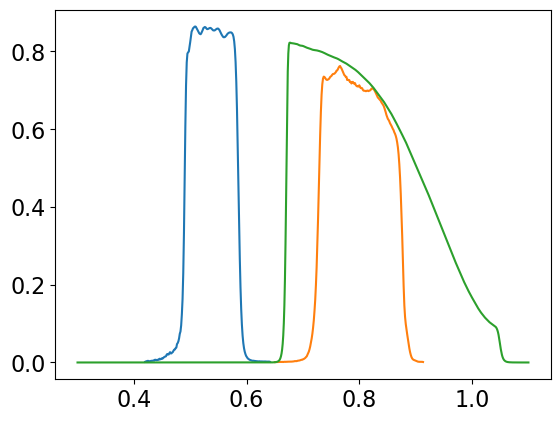

In [46]:
for f in ['V','I', 'Rw']:
    flt = get_filt('ogle,'+f)
    plt.plot(flt.wave/1e4, flt.throughput)
qe = pd.read_csv('~/code/SPISEA/filt_func/ogle/qe.dat', comment='#', sep=' ',
                     names=['wave','min','max'])
rw_filt = pd.read_csv('~/code/SPISEA/filt_func/ogle/Rw_filter.dat', comment='#', sep='\s+', 
                     names=['wave','trans'])
rw_filt.sort_values('wave', inplace=True)
# plt.plot(rw_filt['wave']/1000, rw_filt['trans']/100)
# plt.plot(qe['wave']/10000, qe['min'])
# plt.plot(qe['wave']/10000, qe['max'])
# plt.plot(rw_filt['wave']/1000, rw_qe/100)

In [47]:
qe_avg = np.interp(rw_filt['wave']/1000, qe['wave']/10000, np.mean([qe['min'], qe['max']], axis=0))
rw_qe = qe_avg*rw_filt['trans'].to_numpy()

#np.savetxt('/Users/mhuston/code/SPISEA/filt_func/ogle/Rw.dat', np.array([rw_filt['wave']*10, rw_qe/100]).T, fmt='%.10f')

/Users/mhuston/code/SPISEA/spisea/filters.py:364: UserWarning: Gaia version dr2_rev not recommended, use edr3 for the latest version
  warnings.warn(msg)


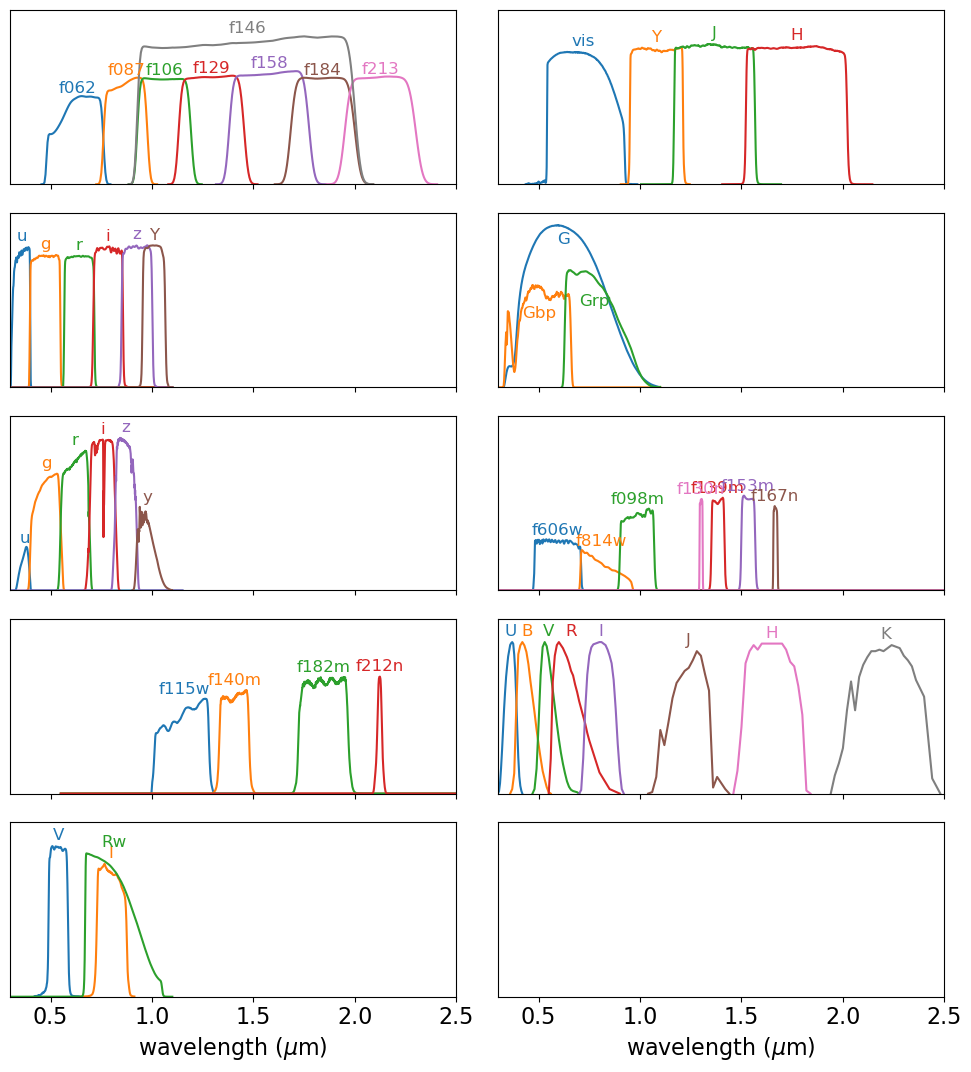

In [51]:
fig,ax = plt.subplots(nrows=5,ncols=2,sharex=True, figsize=(10,11))#,gridspec_kw={"hspace":0.1})
for i,flt_str in enumerate(filts[:-1]):
    flt = get_filt(flt_str)
    ax[0][0].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[0][0].text(filt_avgs[i]/1e4, np.max(flt.throughput), flt_str.split('_')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
flt = get_filt('roman_wfi_f146')
ax[0][0].plot(flt.wave/1e4, flt.throughput*1.3, c="gray")
ax[0][0].text(filt_avgs[-1]/1e4, np.max(flt.throughput)*1.3, "f146", c="gray",
            ha='center', va='bottom', fontsize=12)    

for i,flt_str in enumerate(['euclid,vis']+roman_filters[1]):
    flt = get_filt(flt_str)
    ax[0][1].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[0][1].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
for i,flt_str in enumerate(roman_filters[2]):
    flt = get_filt(flt_str)
    ax[1][0].plot(flt.wave/1e4, flt.throughput/180, c="C"+str(i))
    ax[1][0].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02/180, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
for i,flt_str in enumerate(roman_filters[3]):
    flt = get_filt(flt_str)
    fac1 = [1.5,1.0,1.0][i]
    fac2 = [1.8,1.0,1.0][i]
    ax[1][1].plot(flt.wave/1e4, flt.throughput*fac1, c="C"+str(i))
    ax[1][1].text(flt.pivot()/1e4, np.max(flt.throughput)*0.8*fac2, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='top', fontsize=12)
for i,flt_str in enumerate(roman_filters[4]):
    flt = get_filt(flt_str)
    ax[2][0].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[2][0].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
for i,flt_str in enumerate(roman_filters[5]):
    flt = get_filt(flt_str)
    ax[2][1].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[2][1].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
for i,flt_str in enumerate(roman_filters[6][:4]):
    flt = get_filt(flt_str)
    ax[3][0].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[3][0].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
for i,flt_str in enumerate(roman_filters[7]):
    flt = get_filt(flt_str)
    ax[3][1].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[3][1].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
for i,flt_str in enumerate(roman_filters[8]):
    flt = get_filt(flt_str)
    ax[4][0].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[4][0].text(flt.avgwave()/1e4, np.max(flt.throughput)*1.02, flt_str.split(',')[-1], c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
    
ax[4][0].set_xlabel(r'wavelength ($\mu$m)'); ax[4][1].set_xlabel(r'wavelength ($\mu$m)')
ax[0][0].set_ylim(0,1.05); ax[0][1].set_ylim(0,1.0)
ax[1][0].set_ylim(0,0.67); ax[1][1].set_ylim(0,1.15)
ax[2][0].set_ylim(0,0.72); ax[2][1].set_ylim(0,1)
ax[3][0].set_ylim(0,0.72); ax[3][1].set_ylim(0,1.15)
ax[4][0].set_ylim(0,1);

#ax[0][0].set_xlim(0.3,2.5)
for axiset in ax:
    for axi in axiset:
        axi.set_xlim(0.3,2.5)
        #axi.set_xscale('log')
        axi.set_yticks([])
fig.tight_layout()
fig.savefig('figures/roman_filters_extra.pdf')

In [52]:
spec1 = atm_func(metallicity=0, temperature=2_500, gravity=4.5)
spec2 = atm_func(metallicity=0, temperature=10_000, gravity=2.0)

In [53]:
spec1.fluxunits

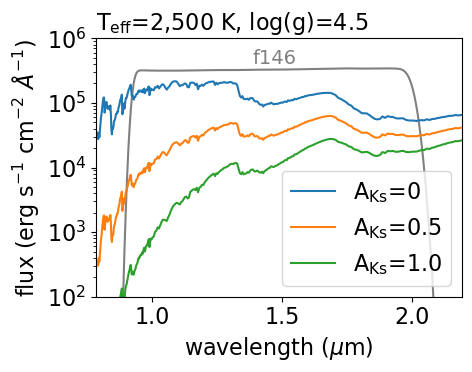

In [56]:
flt = get_filt('roman_wfi_f146')
filt_scale = 5e5
plt.figure(figsize=(5,4))
plt.plot(flt.wave/1e4, flt.throughput*filt_scale, c="gray")
plt.text(filt_avgs[-1]/1e4, np.max(flt.throughput)*filt_scale, "f146", c="gray",
            ha='center', va='bottom', fontsize=14)    
plt.plot(spec1.wave/1e4, spec1.flux, label=r'A$_{\rm Ks}$=0')
for A_Ks in [0.5,1.0]: #,1.5,2.0]:
    red = red_law.reddening(A_Ks).resample(spec1.wave)
    plt.plot(spec1.wave/1e4, (spec1*red).flux, label=fr'A$_{{\rm Ks}}$={A_Ks:.1f}')
plt.xlim(min(flt.wave/1e4)-0.1,max(flt.wave/1e4)+0.1)
plt.ylim(1e2,1e6)
plt.yscale('log')
plt.legend(loc=4)
plt.xlabel(r'wavelength ($\mu$m)')
plt.ylabel(r'flux (erg s$^{−1}$ cm$^{−2}$ $\AA^{−1}$)')
plt.title(r'T$_{\rm eff}$=2,500 K, log(g)=4.5', fontsize=16, loc='left')
plt.tight_layout()
plt.savefig('figures/ext_spectrum1.png')
plt.savefig('figures/ext_spectrum1.pdf')

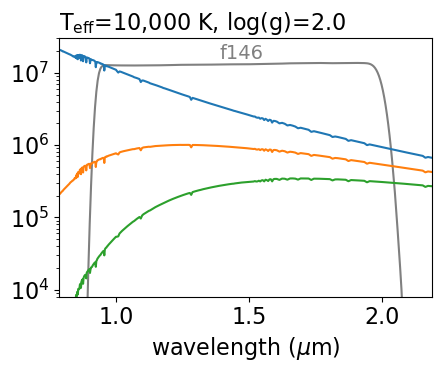

In [57]:
flt = get_filt('roman_wfi_f146')
filt_scale = 2e7
plt.figure(figsize=(4.7,4))
plt.plot(flt.wave/1e4, flt.throughput*filt_scale, c="gray")
plt.text(filt_avgs[-1]/1e4, np.max(flt.throughput)*filt_scale, "f146", c="gray",
            ha='center', va='bottom', fontsize=14)    
plt.plot(spec2.wave/1e4, spec2.flux, label=r'A$_{\rm Ks}$=0')
for A_Ks in [0.5,1.0]: #,1.5,2.0]:
    red = red_law.reddening(A_Ks).resample(spec2.wave)
    plt.plot(spec2.wave/1e4, (spec2*red).flux, label=fr'A$_{{\rm Ks}}$={A_Ks:.1f}')
plt.xlim(min(flt.wave/1e4)-0.1,max(flt.wave/1e4)+0.1)
plt.ylim(8e3,3e7)
plt.yscale('log')
#plt.legend(loc=4)
plt.xlabel(r'wavelength ($\mu$m)')
#plt.ylabel(r'roman_wfi_flux (erg s$^{−1}$ cm$^{−2}$ $\AA^{−1}$)')
plt.title(r'T$_{\rm eff}$=10,000 K, log(g)=2.0', fontsize=16, loc='left')
plt.tight_layout()
plt.savefig('figures/ext_spectrum2.png')
plt.savefig('figures/ext_spectrum2.pdf')

# MISC

In [17]:
# An LLM was used for the first draft of this cell

import os
from spisea import synthetic

# 1. Structure the filter lists mapped exactly to your LaTeX categories
# Format: (LaTeX Instrument Display Name, [ (LaTeX Filter Name, SPISEA string identifier), ... ])
filter_groups = [
    ("Roman WFI\\tablenotemark{a}", [
        ("F062", "roman,wfi,f062"), ("F087", "roman,wfi,f087"), 
        ("F106", "roman,wfi,f106"), ("F129", "roman,wfi,f129"), 
        ("F158", "roman,wfi,f158"), ("F184", "roman,wfi,f184"), 
        ("F213", "roman,wfi,f213"), ("F146", "roman,wfi,f146")
    ]),
    ("Hubble WFC3\\tablenotemark{b}", [
        ("F390W", "wfc3,uvis1,f390w"), ("F555W", "wfc3,uvis1,f555w"),
        ("F606W", "wfc3,uvis1,f606w"), ("F814W", "wfc3,uvis1,f814w"), 
        ("F098M", "wfc3,ir,f098m"), ("F139M", "wfc3,ir,f139m"), 
        ("F153M", "wfc3,ir,f153m"), ("F167N", "wfc3,ir,f167n"), 
        ("F130N", "wfc3,ir,f130n"),
        ("F110W", "wfc3,ir,f110w"), ("F160W", "wfc3,ir,f160w")
    ]),
    ("JWST NIRCam\\tablenotemark{c}", [
        ("F115W", "jwst,f115w"), ("F140M", "jwst,f140m"), 
        ("F182M", "jwst,f182m"), ("F212N", "jwst,f212n"), 
        ("F323N", "jwst,f323n"), ("F360M", "jwst,f360m"), 
        ("F405N", "jwst,f405n"), ("F480M", "jwst,f480m")
    ]),
    ("Gaia\\tablenotemark{d}", [
        ("G", "gaia,edr3,G"), 
        ("G$_{\\rm bp}$", "gaia,edr3,Gbp"), 
        ("G$_{\\rm rp}$", "gaia,edr3,Grp")
    ]),
    ("Euclid\\tablenotemark{e}", [
        ("Y", "euclid,Y"), ("J", "euclid,J"), 
        ("H", "euclid,H"), ("VIS", "euclid,vis")
    ]),
    ("DECam\\tablenotemark{f}", [
        ("u", "decam,u"), ("g", "decam,g"), ("r", "decam,r"), 
        ("i", "decam,i"), ("z", "decam,z"), ("Y", "decam,Y")
    ]),
    ("Rubin\\tablenotemark{g}", [
        ("u", "rubin,u"), ("g", "rubin,g"), ("r", "rubin,r"), 
        ("i", "rubin,i"), ("z", "rubin,z"), ("y", "rubin,y")
    ]),
    ("OGLE\\tablenotemark{h}", [
        ("V", "ogle,V"), ("I","ogle,I"),
        ("R$_{\\rm w}$", "ogle,Rw")
    ]),
    ("Generic\\tablenotemark{i}", [
        ("U", "bessell,U"), ("B", "bessell,B"), ("V", "bessell,V"), 
        ("R", "bessell,R"), ("I", "bessell,I"), 
        ("J", "jg,J"), ("H", "jg,H"), ("K", "jg,K")
    ])
]

# 2. Build the dynamic LaTeX data block
latex_data_rows = []

for idx, (set_name, filter_list) in enumerate(filter_groups):
    for f_idx, (latex_filter, spisea_id) in enumerate(filter_list):
        # Leave the "Set" column blank if it is not the first row of that section
        current_set = set_name if f_idx == 0 else ""
        
        # Query SPISEA conversion functions
        ab_vega = synthetic.calc_ab_vega_filter_conversion(spisea_id).value
        st_vega = synthetic.calc_st_vega_filter_conversion(spisea_id).value

        # Compute specific target math: M_AB - M_ST = (M_AB - M_Vega) - (M_ST - M_Vega)
        ab_st = ab_vega - st_vega

        # Format numbers to 3 decimal places
        val_ab_vega = f"{ab_vega:.3f}"
        val_ab_st = f"{ab_st:.3f}"

        # Construct the LaTeX row string
        row_str = f"{current_set} & {latex_filter} & {val_ab_vega} & {val_ab_st} \\\\"
        latex_data_rows.append(row_str)

# Join all generated data lines with standard LaTeX newline formatting
data_block = "\n".join(latex_data_rows)

# 3. Inject data into your structured template frame
latex_template = f"""\\begin{{deluxetable}}{{llll}} 
\\tablecaption{{List of filters used in this work with conversion values for Vega and ST magnitudes to AB, as our results are presented for AB magnitudes only.}} 
\\tablehead{{\\colhead{{Set}} & \\colhead{{Filter}} & \\colhead{{M$_{{\\rm AB}}$-M$_{{\\rm Vega}}$}} & \\colhead{{M$_{{\\rm AB}}$-M$_{{\\rm ST}}$}}}} 
\\startdata 
{data_block}
\\enddata 
\\tablenotetext{{a}}{{}} 
\\tablenotetext{{b}}{{}} 
\\tablenotetext{{c}}{{}} 
\\tablenotetext{{d}}{{EDR3 bandpasses \\citep{{Riello2021}}}} 
\\tablenotetext{{e}}{{}} 
\\tablenotetext{{f}}{{}} 
\\tablenotetext{{g}}{{}} 
\\tablenotetext{{h}}{{}} 
\\tablenotetext{{i}}{{}} 
\\end{{deluxetable}}"""

# 4. Save the compiled text to disk
output_file = "filter_table.tex"
with open(output_file, "w") as f:
    f.write(latex_template)

print(f"LaTeX template populated and successfully exported to '{output_file}'!")


For roman,wfi,f062, m_ab - m_vega = 0.14709092032372728 mag(AB / VEGA)
For roman,wfi,f062, m_st - m_vega = 0.4485655513149185 mag(ST / VEGA)
For roman,wfi,f087, m_ab - m_vega = 0.4965860048596544 mag(AB / VEGA)
For roman,wfi,f087, m_st - m_vega = 1.5011306617393418 mag(ST / VEGA)
For roman,wfi,f106, m_ab - m_vega = 0.6634601723489354 mag(AB / VEGA)
For roman,wfi,f106, m_st - m_vega = 2.091069240236887 mag(ST / VEGA)
For roman,wfi,f129, m_ab - m_vega = 0.9719886275971806 mag(AB / VEGA)
For roman,wfi,f129, m_st - m_vega = 2.8331118284739136 mag(ST / VEGA)
For roman,wfi,f158, m_ab - m_vega = 1.3044722675728742 mag(AB / VEGA)
For roman,wfi,f158, m_st - m_vega = 3.598640444534609 mag(ST / VEGA)
For roman,wfi,f184, m_ab - m_vega = 1.5712118181112267 mag(AB / VEGA)
For roman,wfi,f184, m_st - m_vega = 4.202554323134333 mag(ST / VEGA)
For roman,wfi,f213, m_ab - m_vega = 1.8256634699591512 mag(AB / VEGA)
For roman,wfi,f213, m_st - m_vega = 4.768357921984802 mag(ST / VEGA)
For roman,wfi,f146, m_a

In [5]:
from astropy.table import Table

In [12]:
tab = Table.read('~/code/SPISEA/filt_func/euclid/H.dat', format='ascii')
for col in tab.columns:
    tab[col][tab[col]<0] = 0.0

In [13]:
tab

WAVE,T_TOTAL,T_FILTER,T_TELESCOPE,T_NI-OA,T_QE
int64,float64,float64,float64,float64,float64
1405,7.39323e-05,9.33327e-05,0.892197,0.939733,0.94479
1406,7.87152e-05,9.94054e-05,0.892028,0.939565,0.944808
1407,8.80195e-05,0.000111139,0.892299,0.939398,0.944827
1408,7.98104e-05,0.000100787,0.892321,0.939232,0.944846
1409,8.04887e-05,0.000101581,0.893008,0.939068,0.944866
1410,8.96503e-05,0.000113211,0.892609,0.938906,0.944887
1411,8.68784e-05,0.000109826,0.891803,0.938745,0.944909
1412,8.0046e-05,0.000101211,0.891739,0.938586,0.944931
1413,9.3824e-05,0.000118704,0.891327,0.938428,0.944954


In [16]:
tab.write('~/code/SPISEA/filt_func/euclid/H.dat', format='ascii',overwrite=True)